# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Avantika Bansal  
**`Roll Number`:**  U20230063  
**`GitHub Branch`:** Avantika_U20230063    

# Imports and Setup

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import classification_report


from rlcmab_sampler import sampler


# Load Datasets

In [2]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

# print(news_df.head())
print(train_users.head())


  user_id   age  income  clicks  purchase_amount  session_duration  \
0   U7392   NaN   23053      10           500.00             17.34   
1   U2702  56.0   20239      11           913.33             22.22   
2   U2461   NaN   13907       9          1252.62             41.57   
3   U7475   NaN   26615      12           500.00             30.17   
4   U6040  32.0   27958      13           500.00             65.27   

   content_variety  engagement_score  num_transactions  avg_monthly_spend  \
0          0.36661          37.29781                 3             187.44   
1          0.61370          59.36342                 5             145.15   
2          0.80368          76.78706                 7             282.03   
3          0.26499          30.19441                10             195.35   
4          0.36385          37.12153                 5             439.68   

   ...  screen_brightness  battery_percentage  cart_abandonment_count  \
0  ...                4.0                 2

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [3]:
# news_df

print(news_df.isnull().sum())
print(news_df.shape)

link                     0
headline                 6
category                 0
short_description    19712
authors              37418
date                     0
dtype: int64
(209527, 6)


Since all rows in the news dataset have the catgory column, we dont need to preprocess any missing values

In [4]:
# train_users, test_users

test_users.isna().sum().sort_values(ascending=False)
test_users['age'] = test_users['age'].fillna(test_users['age'].mean())
train_users.isna().sum().sort_values(ascending=False)
train_users['age'] = train_users['age'].fillna(train_users['age'].mean())



In [5]:
test_users.isna().sum().sort_values(ascending=False)
train_users.isna().sum().sort_values(ascending=False)


user_id                        0
age                            0
income                         0
clicks                         0
purchase_amount                0
session_duration               0
content_variety                0
engagement_score               0
num_transactions               0
avg_monthly_spend              0
avg_cart_value                 0
browsing_depth                 0
revisit_rate                   0
scroll_activity                0
time_on_site                   0
interaction_count              0
preferred_price_range          0
discount_usage_rate            0
wishlist_size                  0
product_views                  0
repeat_purchase_gap (days)     0
churn_risk_score               0
loyalty_index                  0
screen_brightness              0
battery_percentage             0
cart_abandonment_count         0
browser_version                0
background_app_count           0
session_inactivity_duration    0
network_jitter                 0
region_cod

### Feature Encoding

In [6]:
print(news_df['category'].unique())
print(news_df['category'].nunique())


['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']
42


In [7]:
le = LabelEncoder()
news_df['encoded_col'] = le.fit_transform(news_df['category'])

In [8]:
print(news_df['encoded_col'])

0         35
1         35
2          5
3         22
4         35
          ..
209522    32
209523    28
209524    28
209525    28
209526    28
Name: encoded_col, Length: 209527, dtype: int64


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [9]:
train_users= train_users.drop(columns=['user_id', 'browser_version', 'region_code'])  

In [10]:
X = train_users.drop(columns=['label'])
y = train_users['label']

# train_users = pd.get_dummies(train_users, columns=['label'], drop_first=True)


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=63
)

In [12]:
X_train.dtypes
X_train.select_dtypes(include=['object']).columns



Index([], dtype='object')

## Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=63
    # n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_val_pred = rf.predict(X_val)


accuracy = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", accuracy)
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.8275
              precision    recall  f1-score   support

      user_1       0.82      0.85      0.84       146
      user_2       0.86      0.87      0.87       142
      user_3       0.79      0.74      0.76       112

    accuracy                           0.83       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.83      0.83      0.83       400



## Gradient Boosting

In [15]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=63
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_val, y_pred_gb))
print(classification_report(y_val, y_pred_gb))

Gradient Boosting Accuracy: 0.8375
              precision    recall  f1-score   support

      user_1       0.81      0.86      0.83       146
      user_2       0.89      0.87      0.88       142
      user_3       0.82      0.76      0.79       112

    accuracy                           0.84       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.84      0.84       400



Used Gradient Boost and Random Forest. Both have similar accuracy scores. Other classifiers like logistic regression and decision trees have poorer scores

# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


-0.3057385048129042


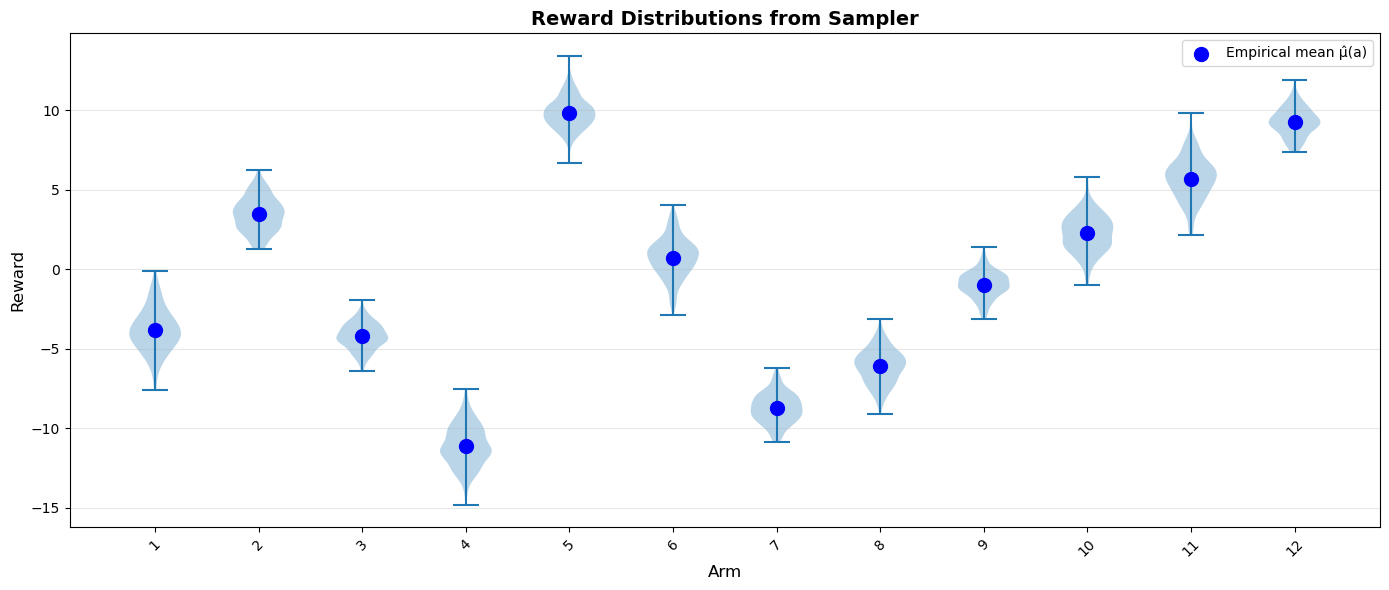

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_arm_reward_distributions(reward_sampler,
                                  arms: int = 12,
                                  samples_per_arm: int = 200) -> None:
    """
    Visualize reward distributions from rlcmab sampler using violin plots.
    """

    # 1️⃣ Create matrix (samples x arms)
    samples_matrix = np.zeros((samples_per_arm, arms))

    # 2️⃣ Collect rewards using sampler.sample(j)
    for trial in range(samples_per_arm):
        for a in range(arms):
            reward = reward_sampler.sample(a)
            samples_matrix[trial, a] = reward

    # 3️⃣ Empirical mean reward
    emp_mean = samples_matrix.mean(axis=0)

    # 4️⃣ Plot violin plots
    fig, ax = plt.subplots(figsize=(14,6))

    parts = ax.violinplot(
        samples_matrix,
        positions=range(arms),
        showmeans=False,
        showmedians=False
    )

    # Plot empirical means
    ax.scatter(range(arms), emp_mean,
               color='blue', s=100, zorder=3,
               label='Empirical mean μ̂(a)', marker='o')

    # nicer labels using your context mapping
    labels = [1, 2, 3, 4, 5,6 ,7 ,8 ,9, 10, 11, 12]

    print(np.mean(emp_mean))

    ax.set_xlabel('Arm', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.set_title('Reward Distributions from Sampler', fontsize=14, fontweight='bold')
    ax.set_xticks(range(arms))
    ax.set_xticklabels(labels, rotation=45)

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

reward_sampler = sampler(63)

plot_arm_reward_distributions(reward_sampler, samples_per_arm=200)

In [17]:
class BanditAgent:
    """
    An agent that learns to select actions in a k-armed bandit problem.
    """
    
    def __init__(self, k: int, epsilon: float = 0.3, 
                 step_size: float = None, initial_value: float = -0.3, c: float = 2.0, tao: float=0.1):

        self.k = k
        self.epsilon = epsilon
        self.step_size = step_size

        self.c = c
        self.tao = tao
        self.t = 0
        
        self.Q_a = np.ones([k]) * initial_value
        self.N_a = np.zeros([k])

        # print(self.Q_a, self.N_a)        
    
    def epsilon_greedy(self) -> int:
        """Select an action using ε-greedy policy."""
        
        random = np.random.rand()
        if random < self.epsilon:
            action = np.random.randint(self.k)
        else:
            action = np.argmax(self.Q_a)

        # max_value = np.max(self.Q_a)
        # candidates = np.where(self.Q_a == max_value)[0]
        # action = np.random.choice(candidates)    
        
        return action
    
    def ucb(self) -> int:
        """Select an action using ucb policy."""
        
        for a in range(self.k):
            if self.N_a[a] == 0:
                return a

        ucb_values = self.Q_a + self.c * np.sqrt(
            np.log(self.t) / self.N_a
        )

        max_value = np.max(ucb_values)
        candidates = np.where(ucb_values == max_value)[0]
        return np.random.choice(candidates)
    
    def soft_max(self) -> int:

        Q = self.Q_a

        Q_max = np.max(Q)
        Q_stable = Q- Q_max

        pi = np.exp(Q_stable/self.tao)/np.sum(np.exp(Q_stable/self.tao))
        # print(pi)

        return np.argmax(pi)
    
    def update(self, action: int, reward: float):
        """ Update action-value estimates after receiving a reward. """
        self.t += 1
        self.N_a[action] +=1

        if self.step_size is None:
            alpha = 1.0 / self.N_a[action]   
        else:
            alpha = self.step_size           

        self.Q_a[action] = self.Q_a[action] + alpha*(reward - self.Q_a[action])

    
    def reset(self, initial_value: float = 0.0):
        """Reset the agent for a new run."""
        self.Q_a = np.ones([self.k])*initial_value
        self.N_a = np.zeros([self.k])
        self.t = 0


agent = BanditAgent(12)

## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [28]:
def run_experiment(epsilon: int=0.1,
                    steps: int = 200):
    """
    Run a single experiment: agent interacting with bandit.
    """
    # agent = BanditAgent(12)
    reward_sampler = sampler(63)

    rewards = np.zeros(steps)

    agents = [
        BanditAgent(4, epsilon=epsilon),
        BanditAgent(4, epsilon=epsilon),
        BanditAgent(4, epsilon=epsilon)
    ]

    for t in range(steps):
            context = np.random.randint(3)
            agent = agents[context]

            local_action = agent.epsilon_greedy()

            # map to global arm
            if context == 0:
                global_action = local_action
            elif context == 1:
                global_action = local_action + 4
            else:
                global_action = local_action + 8

            reward = reward_sampler.sample(global_action)

            agent.update(local_action, reward)

            rewards[t] = reward
    
    return rewards, agents

In [32]:
def train_epsilon(epsilon: float = 0.1,
                steps: int = 10000,
                runs: int = 2000):

    all_rewards = np.zeros((runs, steps))

    for run in range(runs):

        rewards, _ = run_experiment(epsilon, steps)
        all_rewards[run] = rewards

    avg_rewards = all_rewards.mean(axis=0)

    return avg_rewards


[[ -3.82730164   3.51233864  -4.1176056  -11.27295631]
 [  9.96368726   0.56871231  -8.6277381   -5.7219338 ]
 [ -1.02851169   2.11552301   5.81420211   9.19272734]]


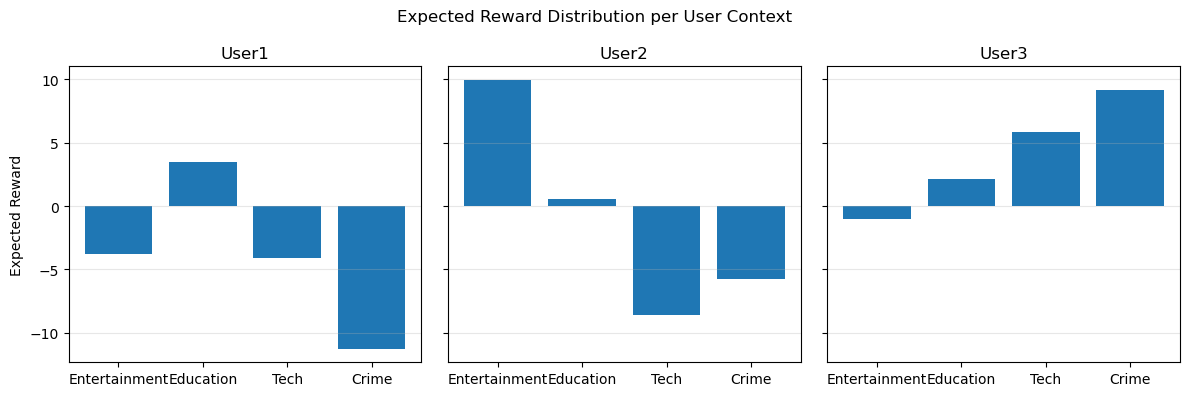

In [33]:
def compute_expected_reward_distribution(epsilon=0.1, steps=5000):

    rewards, agents = run_experiment(epsilon, steps)

    expected_rewards = np.vstack([
        agents[0].Q_a,
        agents[1].Q_a,
        agents[2].Q_a
    ])
    print(expected_rewards)

    return expected_rewards



expected_rewards = compute_expected_reward_distribution(0.1, 5000)
def plot_expected_rewards_bars(expected_rewards):

    news_labels = ["Entertainment","Education","Tech","Crime"]
    users = ["User1","User2","User3"]

    fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)

    for u in range(3):

        axs[u].bar(news_labels, expected_rewards[u])
        axs[u].set_title(users[u])
        # axs[u].set_ylim(0, 1)
        axs[u].grid(axis='y', alpha=0.3)

    axs[0].set_ylabel("Expected Reward")

    plt.suptitle("Expected Reward Distribution per User Context")
    plt.tight_layout()
    plt.show()

plot_expected_rewards_bars(expected_rewards)



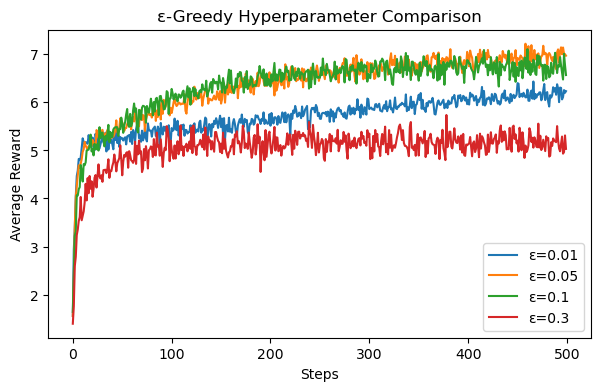

In [34]:
epsilons = [0.01, 0.05, 0.1, 0.3]

plt.figure(figsize=(7,4))

for eps in epsilons:

    avg_rewards = train_epsilon(epsilon=eps, steps=500, runs=1000)
    plt.plot(avg_rewards, label=f"ε={eps}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")

plt.title("ε-Greedy Hyperparameter Comparison")
plt.legend()
plt.show()


In [ ]:
# agent = BanditAgent(12)
# reward_sampler = sampler(63)

# T=200
# for t in range(T):
#     action = agent.epsilon_greedy()
#     reward = reward_sampler.sample(action)
#     agent.update(action, reward)


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [36]:
def run_experiment_ucb(c=2.0, steps=200):

    reward_sampler = sampler(63)
    rewards = np.zeros(steps)

    agents = [
        BanditAgent(4, c=c),
        BanditAgent(4, c=c),
        BanditAgent(4, c=c)
    ]
    

    for t in range(steps):

        context = np.random.randint(3)
        agent = agents[context]

        local_action = agent.ucb()

        if context == 0:
            global_action = local_action
        elif context == 1:
            global_action = local_action + 4
        else:
            global_action = local_action + 8

        reward = reward_sampler.sample(global_action)
        agent.update(local_action, reward)

        rewards[t] = reward

    return rewards


In [37]:
def train_ucb(c=2.0, steps=5000, runs=200):

    all_rewards = np.zeros((runs, steps))

    for r in tqdm(range(runs), desc=f"UCB (c={c})", leave=False):
        rewards = run_experiment_ucb(steps=steps)
        all_rewards[r] = rewards

    return all_rewards.mean(axis=0)


[[ -4.21339028   3.47524033  -4.35765885 -10.80479227]
 [  9.96409106   0.74723315  -8.91119697  -6.06308136]
 [ -0.92285881   2.08471296   5.58869946   9.18230094]]


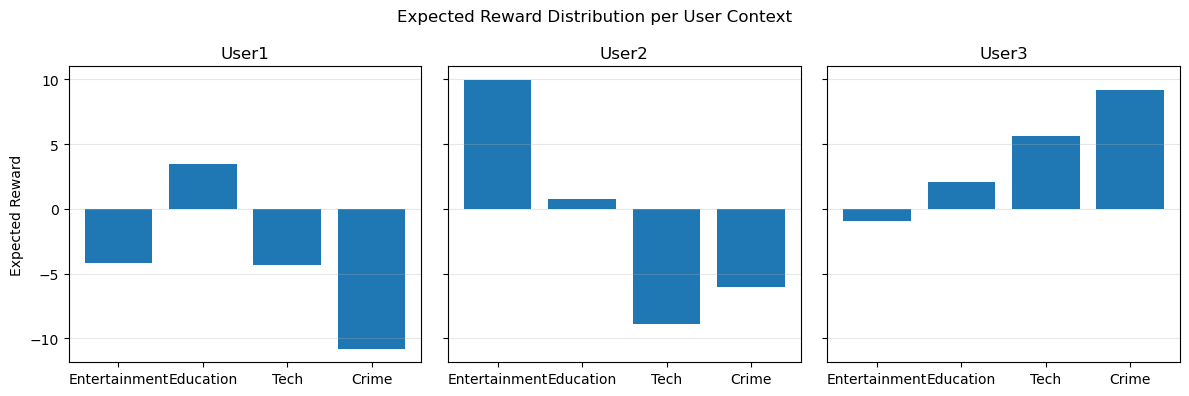

In [38]:
def compute_expected_reward_distribution_ucb(c=0.1, steps=5000):

    rewards, agents = run_experiment(c, steps)

    expected_rewards = np.vstack([
        agents[0].Q_a,
        agents[1].Q_a,
        agents[2].Q_a
    ])
    print(expected_rewards)

    return expected_rewards


expected_rewards = compute_expected_reward_distribution(0.1, 5000)
def plot_expected_rewards_bars(expected_rewards):

    news_labels = ["Entertainment","Education","Tech","Crime"]
    users = ["User1","User2","User3"]

    fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)

    for u in range(3):

        axs[u].bar(news_labels, expected_rewards[u])
        axs[u].set_title(users[u])
        # axs[u].set_ylim(0, 1)
        axs[u].grid(axis='y', alpha=0.3)

    axs[0].set_ylabel("Expected Reward")

    plt.suptitle("Expected Reward Distribution per User Context")
    plt.tight_layout()
    plt.show()

plot_expected_rewards_bars(expected_rewards)



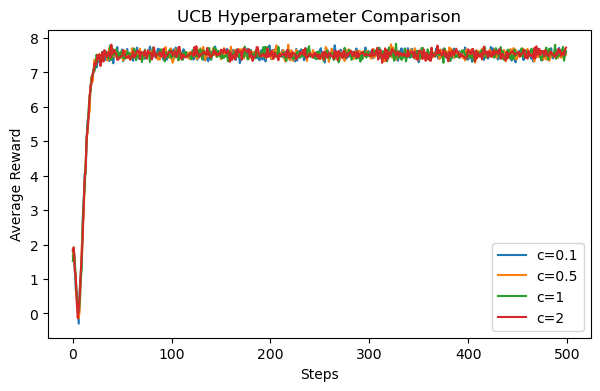

In [39]:
c_options = [0.1, 0.5, 1, 2]

plt.figure(figsize=(7,4))

for c in c_options:

    avg_rewards = train_ucb(c=c, steps=500, runs=1000)
    plt.plot(avg_rewards, label=f"c={c}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("UCB Hyperparameter Comparison")
plt.legend()
plt.show()

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.

In [40]:
def run_experiment_softmax(tau=0.5, steps=200):

    reward_sampler = sampler(63)
    rewards = np.zeros(steps)

    agents = [
        BanditAgent(4, tao=tau),
        BanditAgent(4, tao=tau),
        BanditAgent(4, tao=tau)
    ]

    for t in range(steps):

        context = np.random.randint(3)
        agent = agents[context]

        local_action = agent.soft_max()

        if context == 0:
            global_action = local_action
        elif context == 1:
            global_action = local_action + 4
        else:
            global_action = local_action + 8

        reward = reward_sampler.sample(global_action)
        agent.update(local_action, reward)

        rewards[t] = reward

    return rewards


In [41]:
def train_softmax(tau=0.5, steps=5000, runs=200):

    all_rewards = np.zeros((runs, steps))

    for r in tqdm(range(runs), desc=f"softmax (t={tau})", leave=False):
        rewards = run_experiment_softmax(tau, steps)
        all_rewards[r] = rewards

    return all_rewards.mean(axis=0)


[[ -4.16682803   3.47569542  -4.34858353 -11.26551826]
 [  9.9418109    0.97728132  -8.65876622  -6.37378502]
 [ -0.86265913   2.13203204   5.54473509   9.15515814]]


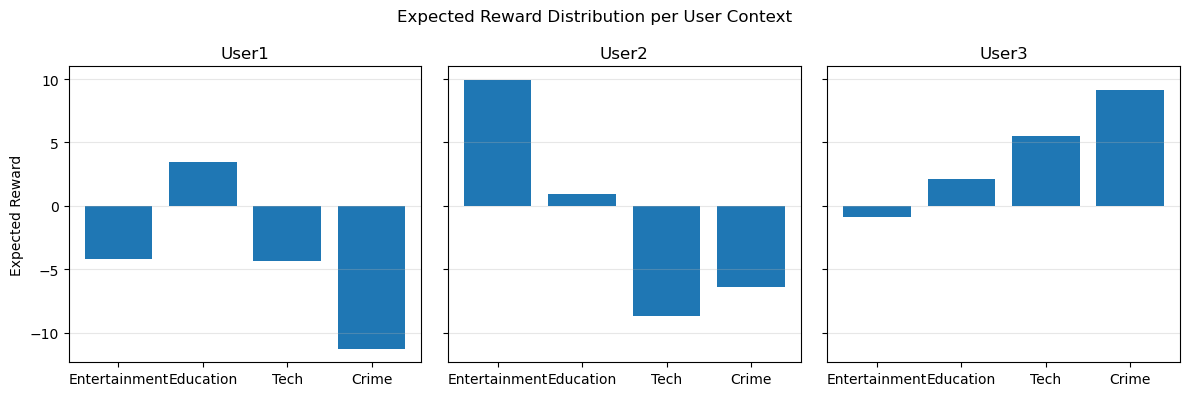

In [42]:
def compute_expected_reward_distribution_softmax(t=1, steps=5000):

    rewards, agents = run_experiment(t, steps)

    expected_rewards = np.vstack([
        agents[0].Q_a,
        agents[1].Q_a,
        agents[2].Q_a
    ])
    print(expected_rewards)

    return expected_rewards


expected_rewards = compute_expected_reward_distribution(0.1, 5000)
def plot_expected_rewards_bars(expected_rewards):

    news_labels = ["Entertainment","Education","Tech","Crime"]
    users = ["User1","User2","User3"]

    fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)

    for u in range(3):

        axs[u].bar(news_labels, expected_rewards[u])
        axs[u].set_title(users[u])
        # axs[u].set_ylim(0, 1)
        axs[u].grid(axis='y', alpha=0.3)

    axs[0].set_ylabel("Expected Reward")

    plt.suptitle("Expected Reward Distribution per User Context")
    plt.tight_layout()
    plt.show()

plot_expected_rewards_bars(expected_rewards)



softmax (t=1):   0%|          | 0/1000 [00:00<?, ?it/s]

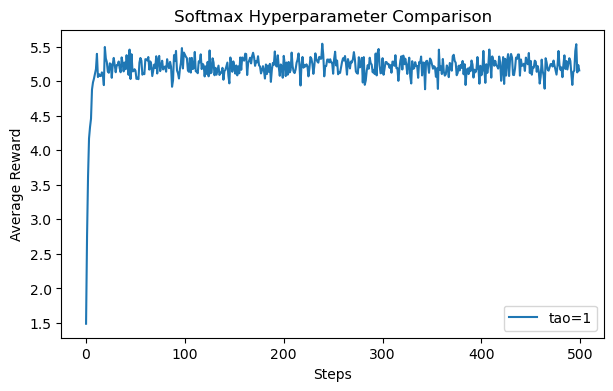

In [43]:
tau = [1]

plt.figure(figsize=(7,4))

for t in tau:

    avg_rewards = train_softmax(tau=t, steps=500, runs=1000)
    plt.plot(avg_rewards, label=f"tao={t}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Softmax Hyperparameter Comparison")
plt.legend()
plt.show()

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [44]:
test_users= test_users.drop(columns=['user_id', 'browser_version', 'region_code'])  

In [45]:
y_test = rf.predict(test_users)
test_users["label"] = y_test
test_users.head()

,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,avg_cart_value,...,churn_risk_score,loyalty_index,screen_brightness,battery_percentage,cart_abandonment_count,background_app_count,session_inactivity_duration,network_jitter,subscriber,label
0,36.0,10000,4,500.00,2.54,0.47162,49.32668,8,229.80,73.26,...,0.514808,13.0,3.0,39.0,3,7,7.86,26.0,True,user_2
1,33.0,19607,8,1906.81,39.74,0.55219,56.42526,4,819.43,520.44,...,0.514304,30.0,4.6,84.0,5,12,2.79,42.0,True,user_1
2,51.0,21049,11,500.00,46.07,0.69961,58.88307,5,113.35,49.14,...,0.364154,21.0,2.1,88.0,7,11,27.50,11.0,False,user_1
3,58.0,25752,13,500.00,60.86,0.86843,86.15690,8,237.13,31.75,...,0.065866,37.0,1.9,34.0,7,15,22.21,34.0,False,user_1
4,32.0,25302,12,2693.22,39.77,0.81805,84.82418,5,1491.56,572.96,...,0.117989,45.0,3.0,6.0,6,8,11.44,0.0,False,user_1


In [46]:
# bandit = BanditAgent(k = 12);
user1_agent = BanditAgent(4, 0.1, None, 0, 1, 0.1)
user2_agent = BanditAgent(4, 0.1, None, 0, 1, 0.1)
user3_agent = BanditAgent(4, 0.1, None, 0, 1, 0.1)
agents = [user1_agent, user2_agent, user3_agent]

steps = 100
reward_sampler = sampler(63)

for t in range(steps):
    for i in range(len(agents)):
        # Select an action
        action_t = agents[i].ucb()
        # Get reward
        action_offset = i * 4
        global_action = action_t + action_offset
        reward_t = reward_sampler.sample(global_action)

        # Update Q function using the reward
        agents[i].update(action_t, reward_t)

# Sample one point from test_users
sampled_user = test_users.sample(n=1, random_state=63).iloc[0]
print(f"{sampled_user["label"]=}")
user_label = sampled_user["label"]

agent_idx = int(user_label[-1]) - 1

sampled_user["label"]='user_2'


In [47]:
action = agents[agent_idx].ucb()
if action == 0:
    news_cat = "ENTERTAINMENT"
elif action == 1:
    news_cat = "EDUCATION"
elif action == 2:
    news_cat = "TECH"
elif action == 3:
    news_cat = "CRIME"

print(f"Recommended news category for the user: {news_cat}")

# Sample an article from the recommended category
recommended_articles = news_df[news_df["category"] == news_cat]
sampled_article = recommended_articles.sample(n=1, random_state=63).iloc[0]
sampled_article

Recommended news category for the user: ENTERTAINMENT


link                 https://www.huffingtonpost.com/entry/james-fra...
headline             James Franco's Band, Daddy, Debuts 'Love In Th...
category                                                 ENTERTAINMENT
short_description    Franco's band, Daddy, is a collaboration with ...
authors                                                            NaN
date                                                        2012-09-22
encoded_col                                                         10
Name: 187496, dtype: object

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


- For the classifier model, multiple classifiers were tried with Random Forest and Gradient Boost giving similar accuracy ouputs.
- Comparing the three algorithms for Bandit policy, Upper Confidence Bound gives the best result, with convergence leading towards the actual value better. 
- For the hyperparameters in each algorithm, epsilon values tried in e-greedy were [0.01, 0.05, 0.1, 0.3], with best results coming from 0.05.
- for UCB algorithm, all t values gave very similar results.
- UCB performed much better than e-greedy, which was also much better than softmax, giving an agerve reward of only 5.5, compared to UCB's reward of 8. 